![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

## Create a HydroDataFrame

We want to create one data frame containing streamflow, meteological information, and SNOTEL for our period of record

In [1]:
from pynhd import NLDI
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
station_id = "11274790" # NWIS id for Tuolumne river at the mouth of Hetch Hetchy Reservoir
basinname = 'TuolumneRiverBasin'

## Load data

We need to load the saved data into our script to process and combine.

We will start with the SNOTEL data

In [3]:
#load snotel data
unprocessed_SNOTEL = {}
#read all files in the following path into the dictionary
path = 'files/SNOTEL'
for filename in os.listdir(path):
    if filename.endswith('.csv'):
        #select the name of the file between the _ and _
        name = filename.split('_')[1] 
        unprocessed_SNOTEL[name] = pd.read_csv(os.path.join(path, filename))
        #make the date a datetime object and set to the index
        unprocessed_SNOTEL[name]['Date'] = pd.to_datetime(unprocessed_SNOTEL[name]['Date'])
        unprocessed_SNOTEL[name].set_index('Date', inplace=True)
        #rename the Snow Water Equivalent (m) Start of Day Values to SWE_cm
        unprocessed_SNOTEL[name].rename(columns={'Snow Water Equivalent (m) Start of Day Values': f"{name}_SWE_cm"}, inplace=True)
        #convert SWE_m to cm
        unprocessed_SNOTEL[name][f"{name}_SWE_cm"] = unprocessed_SNOTEL[name][f"{name}_SWE_cm"] * 100
        #remove the Water_Year column
        unprocessed_SNOTEL[name].drop(columns=['Water_Year'], inplace=True)
        #we need to know how many obs for each DF, print the df name, its length, and the start/end dates
        print(f"{name}: {len(unprocessed_SNOTEL[name])} start date: {unprocessed_SNOTEL[name].index.min()} end date: {unprocessed_SNOTEL[name].index.max()}")
    



TUM: 15288 start date: 1980-01-10 00:00:00 end date: 2021-11-17 00:00:00
DAN: 14936 start date: 1980-10-26 00:00:00 end date: 2021-09-16 00:00:00
SLI: 14273 start date: 1982-10-21 00:00:00 end date: 2021-11-17 00:00:00
TES: 629 start date: 2005-03-01 00:00:00 end date: 2006-11-19 00:00:00


In [4]:
#The TES site is missing many values and will not be useful for our analysis, remove it
unprocessed_SNOTEL.pop('TES', None)

#The site with the latest start date will guide the rest
latest_start_date = max([df.index.min() for df in unprocessed_SNOTEL.values()])

#The site with the earliest end date will guide the rest
soonest_end_date = min([df.index.max() for df in unprocessed_SNOTEL.values()])
for key in unprocessed_SNOTEL.keys():
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index >= latest_start_date]
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index <= soonest_end_date]

#merge all dictionary dataframes into one larger dataframe
SNOTEL_df = pd.concat(unprocessed_SNOTEL.values(), axis=1)
#set the date index to be the index of the first dataframe in the dictionary

SNOTEL_df.head()

,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm
Date,,,
1982-10-21,0.000,NaN,0.000
1982-10-22,0.508,NaN,2.286
1982-10-23,1.270,NaN,2.286
1982-10-24,1.778,NaN,2.286
1982-10-25,2.032,NaN,2.540


## Load the meteorologogical data from Daymet and NLDAS

In [5]:
#Read the data from PyDayMet 
PyDayMet_df = pd.read_csv(f"files/PyDayMet/PyDayMet_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
PyDayMet_df['Date'] = pd.to_datetime(PyDayMet_df['Date'])
PyDayMet_df.set_index('Date', inplace=True)
PyDayMet_df.head()

,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,tmean
Date,,,,,,,,
1980-01-01,33914.08,0.0,356.43,2.943,6.07,-12.54,232.94,-3.235
1980-01-02,33952.03,0.0,363.52,2.943,7.82,-11.91,239.32,-2.045
1980-01-03,33993.09,0.0,364.49,2.943,7.14,-12.50,229.62,-2.680
1980-01-04,34037.22,0.0,340.58,2.943,5.89,-10.41,276.75,-2.260
1980-01-05,34084.41,0.0,318.39,2.943,6.51,-7.77,340.48,-0.630


In [6]:
#Read the data from NLDAS 
NLDAS_df = pd.read_csv(f"files/NLDAS/NLDAS_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
NLDAS_df['Date'] = pd.to_datetime(NLDAS_df['Date'])
NLDAS_df.set_index('Date', inplace=True)
NLDAS_df.head()

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2006-01-01,0.005192,199.833836,1.508087,0.044990,71408.170160,95.234192,0.002439,-7.561317,0.563703,2.807882,5.710911
2006-01-02,0.051767,264.132482,33.055034,0.013663,70799.285724,93.932771,0.004772,-0.944478,4.532128,4.467674,8.864378
2006-01-03,0.016707,214.292827,9.209950,0.030093,71724.799553,101.167170,0.002966,-6.371842,0.575387,4.247262,3.778855
2006-01-04,0.000000,226.581243,0.000000,0.016272,72808.304958,101.368610,0.003240,-3.462835,0.002358,1.485389,1.450410
2006-01-05,0.000000,214.910143,0.000000,0.033974,73429.441947,112.546583,0.002849,1.320337,0.000000,-0.779809,3.417216


## Load the streamflow data

In [7]:
streamflow_df = pd.read_csv(f"files/NWIS/streamflow_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
streamflow_df['Date'] = pd.to_datetime(streamflow_df['Date'])
streamflow_df.set_index('Date', inplace=True)

streamflow_df.head()

,site_no,flow_cms
Date,,
2006-10-13,11274790,0.611643
2006-10-14,11274790,0.563504
2006-10-15,11274790,0.538019
2006-10-16,11274790,0.504039
2006-10-17,11274790,0.481386


## Load our catchment information

In [8]:
basin_info = pd.read_csv(f"files/basin_info/basin_info_{station_id}.csv")
basin_info.head()

,Unnamed: 0,station_id,Average_Elevation_m,Minimum_Elevation_m,Maximum_Elevation_m,Average_Slope,Area_km2,Open_Water,Perennial_Ice_Snow,"Developed,_Open_Space",...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
0,TuolumneRiverBasin,11274790,2847.0938,1165.1238,3972.5696,0.392479,1249.464814,0.745168,0.374508,0.071823,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824


## Now we can merge into one dataframe

In [9]:
#find the latest start date and the earliest end date for SNOTEL_df, met_df, cleaned
begin_date = max([df.index.min() for df in [SNOTEL_df, PyDayMet_df, streamflow_df, NLDAS_df]]) 
end_date = min([df.index.max() for df in [SNOTEL_df, PyDayMet_df, streamflow_df, NLDAS_df]]) 

#clip each dataframe to have the same begin and end dates
SNOTEL_df = SNOTEL_df[(SNOTEL_df.index >= begin_date) & (SNOTEL_df.index <= end_date)]
PyDayMet_df = PyDayMet_df[(PyDayMet_df.index >= begin_date) & (PyDayMet_df.index <= end_date)]
streamflow_df = streamflow_df[(streamflow_df.index >= begin_date) & (streamflow_df.index <= end_date)]
NLDAS_df = NLDAS_df[(NLDAS_df.index >= begin_date) & (NLDAS_df.index <= end_date)]

In [10]:
#merge the SNOTEL_df, met_df, and streamflow dataframes
Hydro_df = pd.concat([SNOTEL_df, PyDayMet_df, NLDAS_df,streamflow_df], axis=1)
#put the site_no column, second to last, and streamfow column, last column, as the first two columns in the dataframe
cols = Hydro_df.columns.tolist()
cols = cols[-2:] + cols[:-2]
Hydro_df = Hydro_df[cols]
Hydro_df.head()

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,,,,,,,,,,,
2006-10-13,11274790,0.611643,0.0,0.0,0.0,39849.51,0.0,335.15,0.0,12.52,...,223.457644,0.038401,0.139839,72107.765879,174.191132,0.003637,4.295980,0.025121,-2.033486,0.793636
2006-10-14,11274790,0.563504,0.0,0.0,0.0,39705.43,0.0,368.37,0.0,12.76,...,219.173461,0.027793,0.143067,71877.921092,190.454843,0.004275,3.669391,0.014288,-0.926827,-2.149881
2006-10-15,11274790,0.538019,0.0,0.0,0.0,39562.00,0.0,402.91,0.0,15.72,...,221.013230,0.000000,0.156591,72003.823920,180.353373,0.003437,5.069112,0.004031,1.443303,-2.045946
2006-10-16,11274790,0.504039,0.0,0.0,0.0,39419.27,0.0,342.84,0.0,9.39,...,212.436870,0.624320,0.159340,71788.350428,190.753002,0.003852,3.643004,0.001124,4.436657,-0.672672
2006-10-17,11274790,0.481386,0.0,0.0,0.0,39277.27,0.0,327.94,0.0,5.66,...,187.458054,4.542329,0.116995,71563.357945,188.902233,0.002838,-2.503130,0.004309,1.149626,-2.636144


In [11]:
#all of the NaN values here should be 0, fill them
Hydro_df = Hydro_df.fillna(0)
Hydro_df.head()

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,,,,,,,,,,,
2006-10-13,11274790,0.611643,0.0,0.0,0.0,39849.51,0.0,335.15,0.0,12.52,...,223.457644,0.038401,0.139839,72107.765879,174.191132,0.003637,4.295980,0.025121,-2.033486,0.793636
2006-10-14,11274790,0.563504,0.0,0.0,0.0,39705.43,0.0,368.37,0.0,12.76,...,219.173461,0.027793,0.143067,71877.921092,190.454843,0.004275,3.669391,0.014288,-0.926827,-2.149881
2006-10-15,11274790,0.538019,0.0,0.0,0.0,39562.00,0.0,402.91,0.0,15.72,...,221.013230,0.000000,0.156591,72003.823920,180.353373,0.003437,5.069112,0.004031,1.443303,-2.045946
2006-10-16,11274790,0.504039,0.0,0.0,0.0,39419.27,0.0,342.84,0.0,9.39,...,212.436870,0.624320,0.159340,71788.350428,190.753002,0.003852,3.643004,0.001124,4.436657,-0.672672
2006-10-17,11274790,0.481386,0.0,0.0,0.0,39277.27,0.0,327.94,0.0,5.66,...,187.458054,4.542329,0.116995,71563.357945,188.902233,0.002838,-2.503130,0.004309,1.149626,-2.636144


In [12]:
#add in the basin info as columns in the dataframe, repeat the values for each row
for col in basin_info.columns:
    Hydro_df[col] = basin_info[col][0]

Hydro_df.head()

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
Date,,,,,,,,,,,,,,,,,,,,,
2006-10-13,11274790,0.611643,0.0,0.0,0.0,39849.51,0.0,335.15,0.0,12.52,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2006-10-14,11274790,0.563504,0.0,0.0,0.0,39705.43,0.0,368.37,0.0,12.76,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2006-10-15,11274790,0.538019,0.0,0.0,0.0,39562.00,0.0,402.91,0.0,15.72,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2006-10-16,11274790,0.504039,0.0,0.0,0.0,39419.27,0.0,342.84,0.0,9.39,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2006-10-17,11274790,0.481386,0.0,0.0,0.0,39277.27,0.0,327.94,0.0,5.66,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824


In [13]:
#take a look around peak SWE to make sure we have snotel values, early season can be tricky to assess
Hydro_df.loc['2019-03-01':'2019-04-01']

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
Date,,,,,,,,,,,,,,,,,,,,,
2019-03-01,11274790,6.909299,74.422,82.296,122.936,40066.17,14.08,280.15,40.505,3.27,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2019-03-02,11274790,11.071869,75.184,83.058,124.460,40211.76,28.55,185.59,40.371,1.44,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2019-03-03,11274790,10.618800,78.486,86.868,128.524,40357.90,0.00,477.81,40.320,3.90,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2019-03-04,11274790,9.854246,78.232,86.868,128.778,40504.55,0.00,584.53,40.320,5.98,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2019-03-05,11274790,10.448899,78.232,86.614,129.032,40651.69,23.06,278.81,40.279,1.48,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2019-03-06,11274790,12.827510,80.772,89.408,132.334,40799.28,19.66,202.14,40.210,0.18,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2019-03-07,11274790,10.901968,83.312,92.456,135.890,40947.30,7.76,429.45,40.986,1.75,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2019-03-08,11274790,8.919792,83.566,92.710,136.652,41095.72,0.00,516.49,40.986,-3.42,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2019-03-09,11274790,7.560586,83.312,92.710,136.906,41244.50,3.88,460.72,41.375,-1.31,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824


In [14]:
Hydro_df.tail()

,site_no,flow_cms,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
Date,,,,,,,,,,,,,,,,,,,,,
2021-09-12,11274790,0.236728,0.0,0.0,0.0,44482.49,0.0,455.38,0.0,22.28,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2021-09-13,11274790,0.302990,0.0,0.0,0.0,44332.18,0.0,486.88,0.0,22.73,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2021-09-14,11274790,0.275239,0.0,0.0,0.0,44181.67,0.0,447.48,0.0,22.50,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2021-09-15,11274790,0.251170,0.0,0.0,0.0,44031.00,0.0,424.99,0.0,21.18,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2021-09-16,11274790,0.223986,0.0,0.0,0.0,43880.19,0.0,420.08,0.0,19.71,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824


## Data Exploration Exercise #1

Use the combined data frame you created for a **USGS NWIS site other than the example** to explore different data and relationships. Select a single water year (October - September) to explore the following relationships:
* Streamflow and SWE (e.g., Daymet and SWE from Snotel)
* Snowmelt -  SWE and temperature/SW radiation
* Rainfall/runoff response - precipitation and streamflow
* comparison of the NLDAS precipitation and temperature with DayMet precipitation and temperature

In markdown below each figure, write a few sentences describing the relationships and anything that is unexpected. This exercise prepares you for HW#2.


## Data Exploration Exercise #2

Develop a Python script (.py) that you can run in the terminal that collects, processes, and saves your dataframes and a few select figures of interest.

In [13]:
import os
import sys
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath('supporting_scripts'))

# Station config
station_id  = "09330000"
basinname   = "FremontRiverBasin"
water_year  = 2019
wy_start    = f"{water_year - 1}-10-01"
wy_end      = f"{water_year}-09-30"

os.makedirs('figures', exist_ok=True)
print("Setup complete.")
print(f"Station: {station_id} - Fremont River near Bicknell, UT")
print(f"Water Year: {water_year}  ({wy_start} to {wy_end})")

Setup complete.
Station: 09330000 - Fremont River near Bicknell, UT
Water Year: 2019  (2018-10-01 to 2019-09-30)


In [14]:
NLDAS_df = pd.read_csv("files/NLDAS/NLDAS_09330000.csv")
NLDAS_df['Date'] = pd.to_datetime(NLDAS_df['Date'])
NLDAS_df.set_index('Date', inplace=True)
# Convert total_precipitation from kg/m²/s to mm/day
NLDAS_df['prcp_mm_day'] = NLDAS_df['total_precipitation'] * 86400
print(f"NLDAS: {NLDAS_df.index.min()} to {NLDAS_df.index.max()}")
print(f"Columns: {list(NLDAS_df.columns)}")
NLDAS_df.head()

NLDAS: 2006-01-01 00:00:00 to 2021-12-31 00:00:00
Columns: ['convective_fraction', 'longwave_radiation', 'potential_energy', 'potential_evaporation', 'pressure', 'shortwave_radiation', 'specific_humidity', 'temperature', 'total_precipitation', 'wind_u', 'wind_v', 'prcp_mm_day']


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,prcp_mm_day
Date,,,,,,,,,,,,
2006-01-01,0.068364,214.945984,10.357649,0.054106,72753.678503,107.852158,0.003055,-3.338389,0.091463,3.342801,0.910459,7902.375296
2006-01-02,0.000000,254.142714,0.084665,0.067265,73029.484303,91.486908,0.003090,-2.143214,0.161195,-0.559634,4.033410,13927.227233
2006-01-03,0.011927,242.204453,9.225596,0.067936,73256.813998,107.238005,0.003487,-1.811355,0.107383,2.769881,3.616136,9277.884909
2006-01-04,0.000000,197.144062,0.000000,0.024668,74239.713135,109.932230,0.002689,-4.391122,0.012684,1.648244,-0.040291,1095.879590
2006-01-05,0.000000,182.991867,0.000000,0.023489,74969.586306,112.016637,0.002074,-4.712330,0.000000,1.480716,-1.937328,0.000000


In [15]:
from dataretrieval import nwis

streamflow_path = "files/NWIS/streamflow_09330000.csv"
os.makedirs('files/NWIS', exist_ok=True)

if os.path.exists(streamflow_path):
    print("Loading cached streamflow...")
    streamflow_df = pd.read_csv(streamflow_path)
    streamflow_df['Date'] = pd.to_datetime(streamflow_df['Date'])
    streamflow_df.set_index('Date', inplace=True)
else:
    print("Fetching streamflow from NWIS...")
    raw, _ = nwis.get_dv(
        sites=station_id,
        start="2006-01-01",
        end="2021-12-31",
        parameterCd="00060"
    )
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    raw.index.name = 'Date'
    raw['flow_cms'] = raw['00060_Mean'] * 0.0283168
    streamflow_df = raw[['flow_cms']].copy()
    streamflow_df['site_no'] = station_id
    streamflow_df.to_csv(streamflow_path)
    print(f"Saved to {streamflow_path}")

print(f"Streamflow: {streamflow_df.index.min()} to {streamflow_df.index.max()}")
streamflow_df.head()

Fetching streamflow from NWIS...
Saved to files/NWIS/streamflow_09330000.csv
Streamflow: 2006-01-01 00:00:00 to 2021-12-31 00:00:00


,flow_cms,site_no
Date,,
2006-01-01,2.344631,09330000
2006-01-02,2.381443,09330000
2006-01-03,2.429581,09330000
2006-01-04,2.336136,09330000
2006-01-05,2.237027,09330000


In [16]:
# Align date ranges
begin_date = max([NLDAS_df.index.min(), streamflow_df.index.min()])
end_date   = min([NLDAS_df.index.max(), streamflow_df.index.max()])

NLDAS_df      = NLDAS_df[(NLDAS_df.index >= begin_date) & (NLDAS_df.index <= end_date)]
streamflow_df = streamflow_df[(streamflow_df.index >= begin_date) & (streamflow_df.index <= end_date)]

Hydro_df = pd.concat([streamflow_df, NLDAS_df], axis=1)

# Clip to water year
wy_df = Hydro_df[(Hydro_df.index >= wy_start) & (Hydro_df.index <= wy_end)].copy()

print(f"Hydro_df: {Hydro_df.shape}")
print(f"WY{water_year}: {wy_df.shape} rows")
print(f"Columns: {list(wy_df.columns)}")
wy_df[['flow_cms', 'prcp_mm_day', 'temperature', 'shortwave_radiation']].describe()

Hydro_df: (5844, 14)
WY2019: (365, 14) rows
Columns: ['flow_cms', 'site_no', 'convective_fraction', 'longwave_radiation', 'potential_energy', 'potential_evaporation', 'pressure', 'shortwave_radiation', 'specific_humidity', 'temperature', 'total_precipitation', 'wind_u', 'wind_v', 'prcp_mm_day']


,flow_cms,prcp_mm_day,temperature,shortwave_radiation
count,365.000000,365.000000,365.000000,365.000000
mean,1.822376,2910.510680,4.428593,202.866059
std,0.278198,6746.131415,9.218865,73.699334
min,1.268593,0.000000,-15.312387,56.792277
25%,1.656533,0.000000,-2.786536,134.273632
50%,1.778295,52.700545,3.493866,208.454430
75%,1.953859,2064.611247,12.672069,265.843517
max,3.652867,57643.760020,20.607519,332.300672


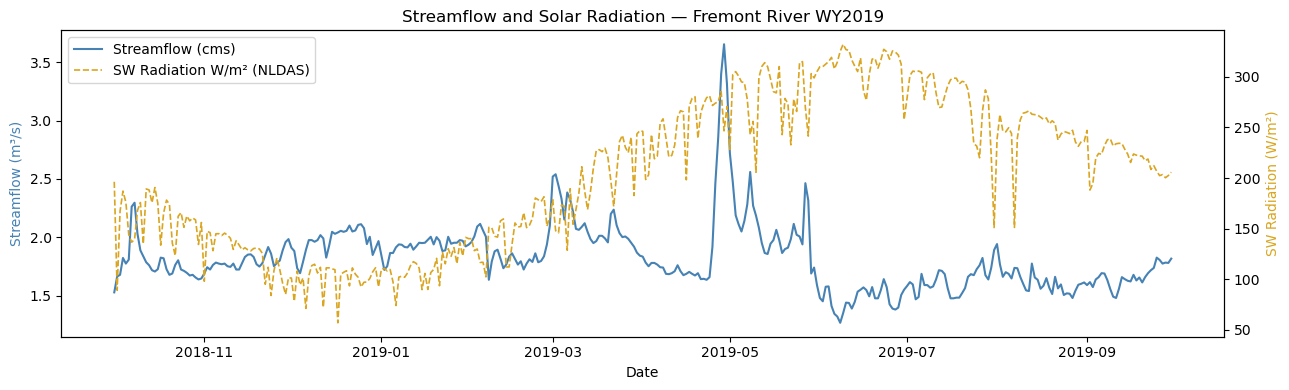

In [17]:
# Note: NLDAS doesn't have a direct SWE variable, so we use shortwave radiation
# as a snowmelt driver proxy alongside streamflow
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.plot(wy_df.index, wy_df['flow_cms'], color='steelblue', lw=1.5, label='Streamflow (cms)')
ax2.plot(wy_df.index, wy_df['shortwave_radiation'], color='goldenrod', lw=1.2,
         linestyle='--', label='SW Radiation W/m² (NLDAS)')

ax1.set_ylabel('Streamflow (m³/s)', color='steelblue')
ax2.set_ylabel('SW Radiation (W/m²)', color='goldenrod')
ax1.set_xlabel('Date')
ax1.set_title(f'Streamflow and Solar Radiation — Fremont River WY{water_year}')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(f'figures/{basinname}_WY{water_year}_streamflow_radiation.png', dpi=150)
plt.show()

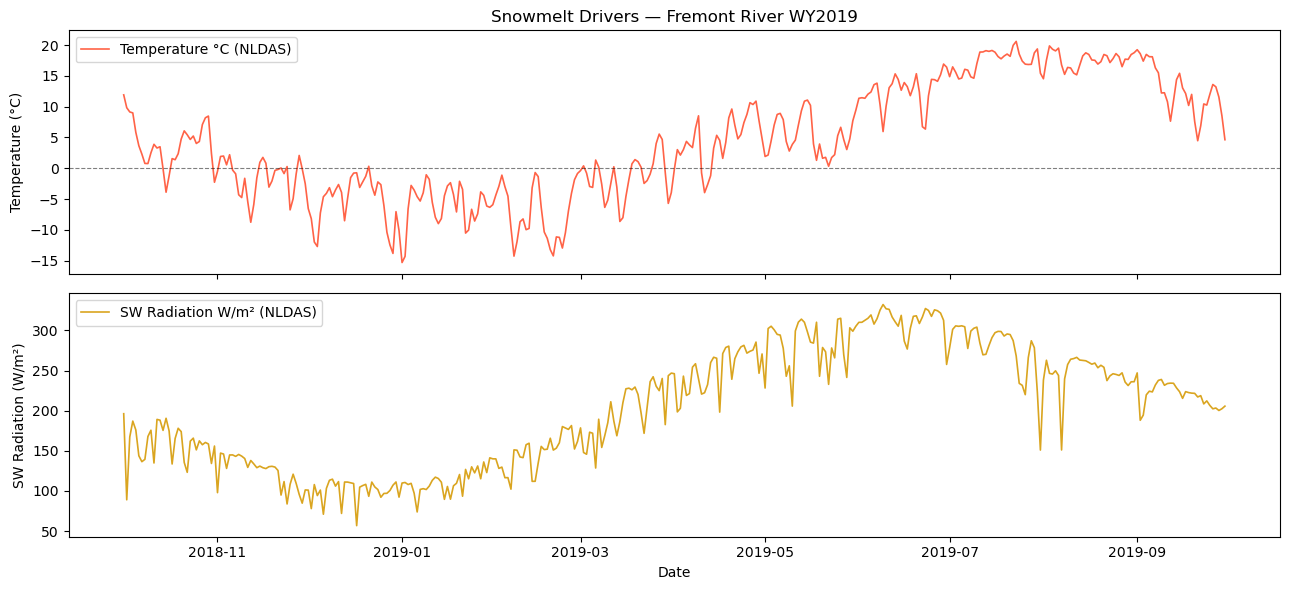

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(wy_df.index, wy_df['temperature'], color='tomato', lw=1.2, label='Temperature °C (NLDAS)')
axes[0].axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title(f'Snowmelt Drivers — Fremont River WY{water_year}')
axes[0].legend(loc='upper left')

axes[1].plot(wy_df.index, wy_df['shortwave_radiation'], color='goldenrod', lw=1.2,
             label='SW Radiation W/m² (NLDAS)')
axes[1].set_ylabel('SW Radiation (W/m²)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'figures/{basinname}_WY{water_year}_snowmelt_drivers.png', dpi=150)
plt.show()

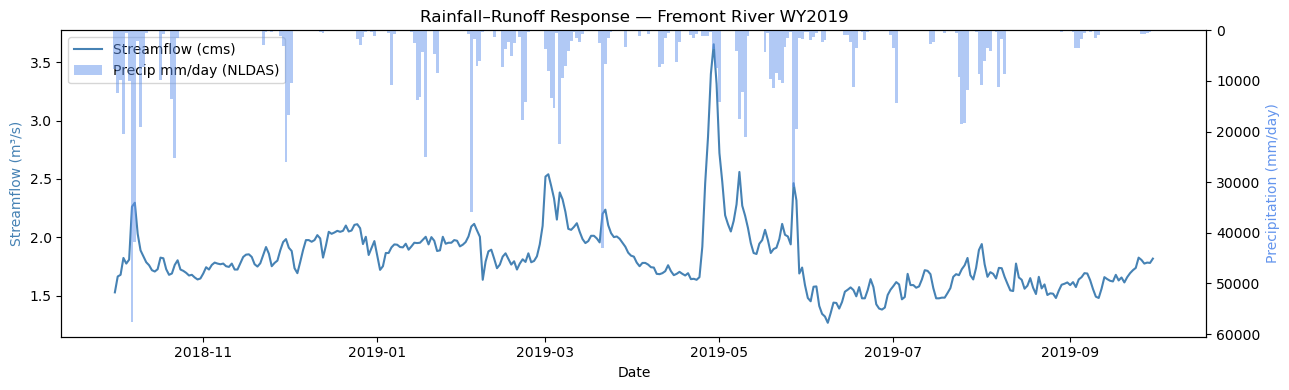

In [19]:
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax2.bar(wy_df.index, wy_df['prcp_mm_day'], color='cornflowerblue',
        alpha=0.5, label='Precip mm/day (NLDAS)', width=1)
ax1.plot(wy_df.index, wy_df['flow_cms'], color='steelblue', lw=1.5, label='Streamflow (cms)')

ax1.set_ylabel('Streamflow (m³/s)', color='steelblue')
ax2.set_ylabel('Precipitation (mm/day)', color='cornflowerblue')
ax2.invert_yaxis()
ax1.set_xlabel('Date')
ax1.set_title(f'Rainfall–Runoff Response — Fremont River WY{water_year}')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(f'figures/{basinname}_WY{water_year}_rainfall_runoff.png', dpi=150)
plt.show()

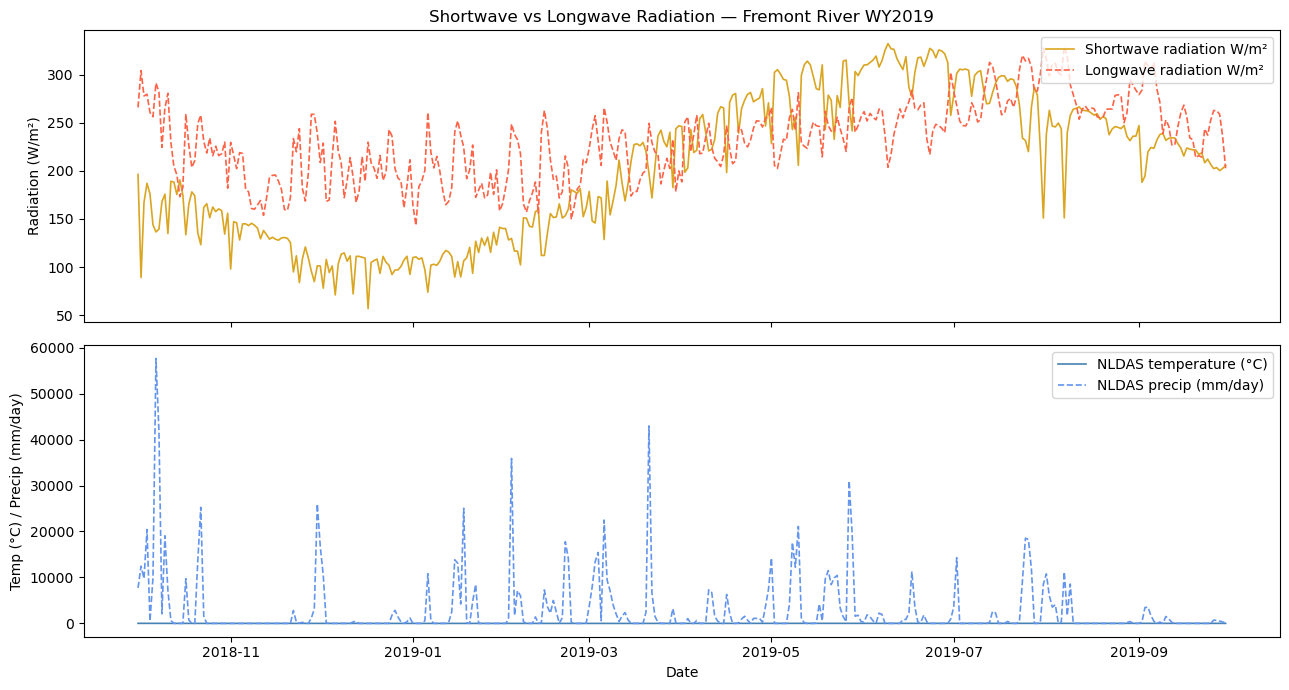

In [20]:
# reflect energy balance: shortwave (incoming solar) vs longwave (thermal emission)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(wy_df.index, wy_df['shortwave_radiation'], color='goldenrod',
             lw=1.2, label='Shortwave radiation W/m²')
axes[0].plot(wy_df.index, wy_df['longwave_radiation'], color='tomato',
             lw=1.2, linestyle='--', label='Longwave radiation W/m²')
axes[0].set_ylabel('Radiation (W/m²)')
axes[0].set_title(f'Shortwave vs Longwave Radiation — Fremont River WY{water_year}')
axes[0].legend(loc='upper right')

axes[1].plot(wy_df.index, wy_df['temperature'], color='steelblue',
             lw=1.2, label='NLDAS temperature (°C)')
axes[1].plot(wy_df.index, wy_df['prcp_mm_day'], color='cornflowerblue',
             lw=1.2, linestyle='--', label='NLDAS precip (mm/day)')
axes[1].set_ylabel('Temp (°C) / Precip (mm/day)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'figures/{basinname}_WY{water_year}_radiation_comparison.png', dpi=150)
plt.show()